In [ ]:
import pandas as pd

In [ ]:
import numpy as np

In [2]:
rng = np.random.default_rng(42)

df_sampling = pd.DataFrame(
    {
        "user_id": np.arange(1, 101),
        "category": rng.choice(["A", "B", "C"], size=100, p=[0.5, 0.3, 0.2]),
        "score": rng.normal(loc=75, scale=10, size=100).round(2),
    }
)

In [3]:
df_sampling.head()

,user_id,category,score
0,1,B,79.00
1,2,A,65.95
2,3,C,71.22
3,4,B,87.99
4,5,A,71.44


In [6]:
df_sampling.shape

(100, 3)

In [7]:
df_sampling['score'].describe()[['mean','std']]

mean    74.859800
std      9.843752
Name: score, dtype: float64

In [8]:
df_sampling['category'].value_counts()

category
A    53
B    33
C    14
Name: count, dtype: int64

In [9]:
df_sampling['category'].value_counts(normalize = True)

category
A    0.53
B    0.33
C    0.14
Name: proportion, dtype: float64

## Random Sampling

In [10]:
rs = df_sampling.sample(n = 30 , random_state=42)

In [11]:
rs['score'].describe()[['mean','std']]

mean    72.739667
std      8.956177
Name: score, dtype: float64

In [12]:
rs.head()

,user_id,category,score
83,84,A,77.19
53,54,B,64.64
70,71,A,73.43
45,46,C,77.68
44,45,C,53.68


In [13]:
rs.groupby('category')['score'].describe()[['mean','std','count']]

,mean,std,count
category,,,
A,73.318000,10.134300,15.0
B,74.975556,6.108523,9.0
C,67.940000,8.961924,6.0


In [14]:
rs['category'].value_counts(normalize= True)

category
A    0.5
B    0.3
C    0.2
Name: proportion, dtype: float64

## Stratified Sampling

In [15]:
stratified_sampling = (df_sampling
                       .groupby('category',group_keys=False)
                       .sample(frac= 0.2 , random_state=42))

stratified_sampling.head()

,user_id,category,score
38,39,A,78.14
83,84,A,77.19
92,93,A,92.24
28,29,A,89.63
85,86,A,86.06


In [16]:
(stratified_sampling
 .groupby('category')['score']
 .describe()[['mean','std','count']])

,mean,std,count
category,,,
A,76.688182,10.510287,11.0
B,78.715714,10.081969,7.0
C,63.650000,5.447054,3.0


In [17]:
(df_sampling
 .groupby('category')['score']
 .describe()[['mean','std','count']])

,mean,std,count
category,,,
A,74.200000,8.973076,53.0
B,76.272424,10.014058,33.0
C,74.027857,12.705514,14.0


In [18]:
print(stratified_sampling.shape)
stratified_sampling['category'].value_counts(normalize=True)

(21, 3)


category
A    0.523810
B    0.333333
C    0.142857
Name: proportion, dtype: float64

In [19]:
print(df_sampling.shape)
df_sampling['category'].value_counts(normalize=True)

(100, 3)


category
A    0.53
B    0.33
C    0.14
Name: proportion, dtype: float64

In [20]:
stratified_sampling = (df_sampling
                       .groupby('category')
                       .sample(n = 10))

In [21]:
stratified_sampling['category'].value_counts()

category
A    10
B    10
C    10
Name: count, dtype: int64

In [22]:
df_sampling.head()

,user_id,category,score
0,1,B,79.00
1,2,A,65.95
2,3,C,71.22
3,4,B,87.99
4,5,A,71.44


In [23]:
len(df_sampling)

100

In [31]:
def control_treatment(df:pd.DataFrame, p:list)->pd.DataFrame:
    rng = np.random.default_rng(42)
    df_sampling_spliting = df.assign(
    group = rng.choice(['control','treatment'], size = len(df_sampling), p = p))

    return df_sampling_spliting

In [32]:
df_sampling_spliting = control_treatment(df_sampling,[0.5,0.5])

In [33]:
df_sampling_spliting.head()

,user_id,category,score,group
0,1,B,79.00,treatment
1,2,A,65.95,control
2,3,C,71.22,treatment
3,4,B,87.99,treatment
4,5,A,71.44,control


In [34]:
df_sampling_spliting['group'].value_counts()

group
control      53
treatment    47
Name: count, dtype: int64

In [35]:
df_sampling_spliting[['group', 'category']].value_counts()

group      category
control    A           53
treatment  B           33
           C           14
Name: count, dtype: int64

In [37]:
df_stratified_split = (
    df_sampling
    .assign(
        group=lambda x: (
            x.groupby("category")["user_id"]
            .transform(
                lambda g: rng.permutation(
                    ["control"] * (len(g)//2) + 
                    ["treatment"] * (len(g) - len(g)//2)
                )
            )
        )
    )
)

In [38]:
df_stratified_split[['group', 'category']].value_counts()

group      category
treatment  A           27
control    A           26
treatment  B           17
control    B           16
treatment  C            7
control    C            7
Name: count, dtype: int64

## Power Analysis With Python

In [39]:
import numpy as np
import pandas as pd
import math
from statsmodels.stats.power import TTestIndPower
from statsmodels.stats.multitest import multipletests
from scipy.stats import ttest_ind
import scipy
import matplotlib.pyplot as plt

In [40]:
N = TTestIndPower().solve_power(effect_size = 0.4, power = 0.8,
                            alpha = 0.05)

N

99.08032514676705

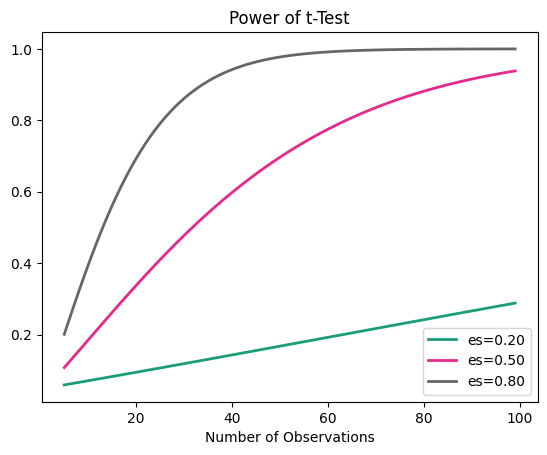

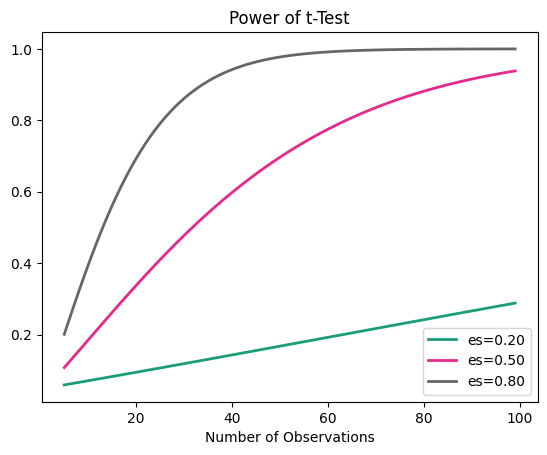

In [41]:
TTestIndPower().plot_power(dep_var='nobs', 
                            nobs=np.array(range(5, 100)), 
                            effect_size=np.array([0.2, 0.5, 0.8]),
                            title='Power of t-Test')

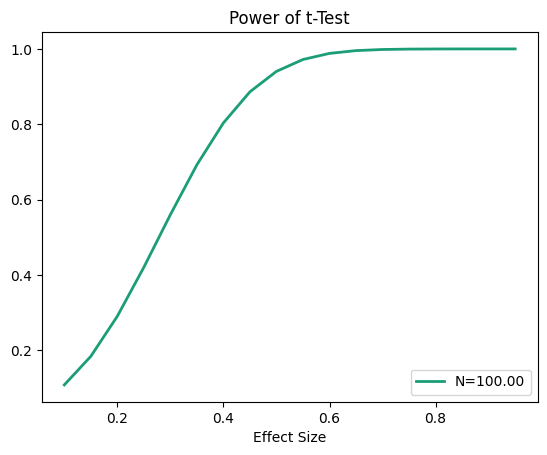

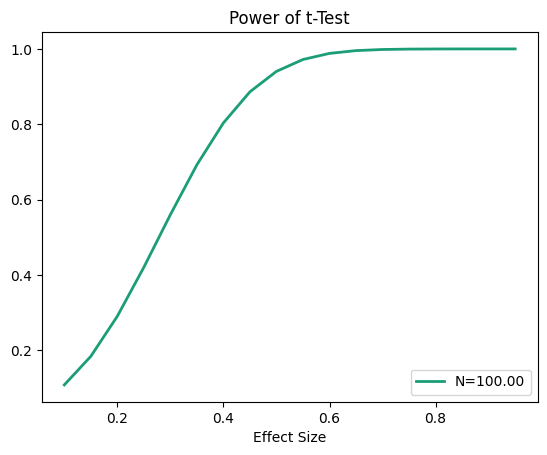

In [42]:
TTestIndPower().plot_power(dep_var='effect_size', nobs= [100],
                                 effect_size=np.arange(0.1, 1, 0.05),
                                 title='Power of t-Test')

## Hypothesis Testing

In [52]:
N = TTestIndPower().solve_power(effect_size = 0.4, power = 0.8,
                            alpha = 0.05)

N


99.08032514676705

In [54]:
N = TTestIndPower().solve_power(effect_size = 0.365, power = 0.8,
                            alpha = 0.05, alternative = 'larger')

N = int(N)
N

93

In [56]:
expr = pd.read_csv('../data/ab_testing/experiment.csv')
expr.head()

,user_id,viewing_time,Group
0,4b5630ee914e848e8d07221556b0a2fb,38.354937,control
1,c01f179e4b57ab8bd9de309e6d576c48,49.534278,control
2,11946e7a3ed5e1776e81c0f0ecd383d0,35.468325,control
3,234a2a5581872457b9fe1187d1616b13,69.014875,control
4,dd4ad37ee474732a009111e3456e7ed7,51.547207,control


In [57]:
expr.groupby('Group')['viewing_time'].mean()

Group
control      48.386186
treatment    52.081302
Name: viewing_time, dtype: float64

## T-test with scipy:

In [58]:
ctrl = expr[expr['Group'] == 'control']['viewing_time']
treatment = expr[expr['Group'] == 'treatment']['viewing_time']

In [59]:
test_res = ttest_ind(treatment, ctrl)
tstat, pvalue=test_res

In [60]:
f"t-statistics: {tstat:.4f}"

't-statistics: 1.6002'

In [61]:
f"p-value: {pvalue:.4f}"

'p-value: 0.1128'

In [62]:
diff=treatment.mean() - ctrl.mean()
sd_pooled=math.sqrt((treatment.std()**2+ ctrl.std()**2)/2)

In [63]:
f"The detected Effect: {diff/sd_pooled:.4f}"

'The detected Effect: 0.3200'

## Practical Significance

In [64]:
def measures(data):
    x1=data.describe().loc['mean','score1']
    x2=data.describe().loc['mean','score2']
    s1=data.describe().loc['std','score1']
    s2=data.describe().loc['std','score2']
    return x1,x2,s1,s2

# -----
def ttest(x1,x2,s1,s2,n):
    t_value=(x1-x2)/math.sqrt(s1**2/n+s2**2/n)
    p_value=scipy.stats.t.sf(abs(t_value), df=n-1)*2
    return f't-value: {t_value:.4f}', f'p-value: {p_value:.4f}'

### Case 1 | low variance

In [65]:
case1=pd.read_csv("../data/ab_testing/case1.csv")
case1.head()

,score1,score2
0,85,87
1,85,86
2,86,87
3,86,86
4,85,86


In [66]:
case1.describe().loc[['count','mean','std']]

,score1,score2
count,20.000000,20.000000
mean,85.550000,86.400000
std,0.510418,0.502625


In [69]:
# t-test for case 1
c1=measures(case1)
ttest(*c1,20)

('t-value: -5.3065', 'p-value: 0.0000')

### Case 2 | huge sample size

In [67]:
case2=pd.read_csv("../data/ab_testing/case2.csv")
case2.head()

,score1,score2
0,88,95
1,89,88
2,91,93
3,94,87
4,87,89


In [68]:
case2.describe().loc[['count','mean','std']]

,score1,score2
count,20.000000,20.000000
mean,90.650000,90.750000
std,2.777257,2.788605


In [70]:
c2 = measures(case2)
c2

(np.float64(90.65),
 np.float64(90.75),
 np.float64(2.777257261172764),
 np.float64(2.7886046312580213))

In [72]:
c2=measures(case2)
ttest(*c2,20)

('t-value: -0.1136', 'p-value: 0.9107')

In [73]:
c2=measures(case2)
ttest(*c2,200)

('t-value: -0.3593', 'p-value: 0.7197')

In [75]:
ttest(*c2,2000)

('t-value: -1.1363', 'p-value: 0.2560')

In [76]:
ttest(*c2,20000)

('t-value: -3.5933', 'p-value: 0.0003')

In [77]:
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests

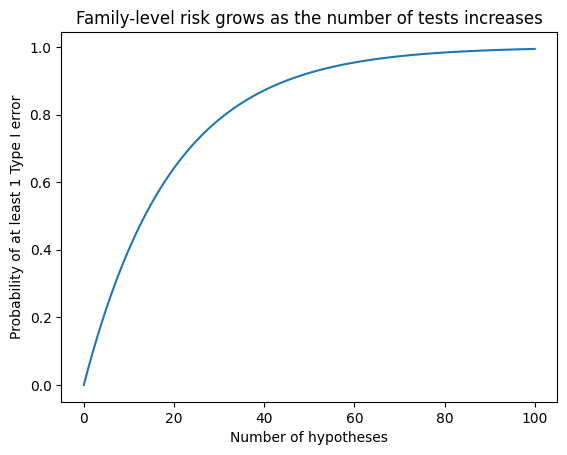

In [78]:
m_tests = np.arange(0, 101)
prob_at_least_one_error = 1 - (1 - 0.05) ** m_tests

plt.figure()
plt.plot(m_tests, prob_at_least_one_error)
plt.xlabel("Number of hypotheses")
plt.ylabel("Probability of at least 1 Type I error")
plt.title("Family-level risk grows as the number of tests increases")
plt.show()